In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
province_risk = pd.read_csv("province_risk_final.csv")
joined_projects = gpd.read_file("all_joined_projects.gpkg", ignore_geometry=True)

joined = joined_projects.groupby('Province')['ApprovedBudgetForContract'].sum().reset_index()
joined.rename(columns={'ApprovedBudgetForContract': 'Total_Budget'}, inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: 'province_risk_final.csv'

In [51]:
name_check = pd.merge(
    province_risk[['SHP_Province']], 
    joined[['Province']], 
    left_on='SHP_Province', 
    right_on='Province', 
    how='outer'
)

name_check = name_check.sort_values(by='SHP_Province')

with pd.option_context('display.max_rows', None):
    print(name_check[['SHP_Province', 'Province']])

           SHP_Province               Province
3                 Aklan                  Aklan
4                 Albay                  Albay
6                Apayao                 Apayao
7                Aurora                 Aurora
9                Bataan                 Bataan
11             Batangas               Batangas
12              Benguet                Benguet
14                Bohol                  Bohol
15             Bukidnon               Bukidnon
16              Bulacan                Bulacan
17              Cagayan                Cagayan
18      Camarines Norte        Camarines Norte
19        Camarines Sur          Camarines Sur
21                Capiz                  Capiz
22          Catanduanes            Catanduanes
23               Cavite                 Cavite
24                 Cebu                   Cebu
25    Compostela Valley                    NaN
26             Cotabato               Cotabato
28       Davao Oriental         Davao Oriental
30      Davao

In [1]:
# This is just 62 provinces
df = pd.merge(province_risk, joined, left_on='SHP_Province', right_on='Province', how='inner')

NameError: name 'pd' is not defined

In [35]:
df['Total_Budget'] = df['Total_Budget'].fillna(0)
df['log_budget'] = np.log1p(df['Total_Budget'])

df['norm_risk'] = (df['risk_score'] - df['risk_score'].min()) / (df['risk_score'].max() - df['risk_score'].min())
df['norm_budget'] = (df['log_budget'] - df['log_budget'].min()) / (df['log_budget'].max() - df['log_budget'].min())

In [36]:
risk_mid = df['norm_risk'].median()
budget_mid = df['norm_budget'].median()

def assign_quadrant(row):
    r = row['norm_risk']
    b = row['norm_budget']
    
    if r >= risk_mid and b < budget_mid:
        return "Bad: High risk, low budget"
    if r < risk_mid and b >= budget_mid:
        return "Bad: Low risk, high budget"
    if r >= risk_mid and b >= budget_mid:
        return "Ideal: High risk, high budget"
    return "Ideal: Low risk, low budget"
    
df['Matrix_Scenario'] = df.apply(assign_quadrant, axis=1)

In [39]:
clean_export = df[['Province', 'risk_score', 'Total_Budget', 'norm_risk', 'norm_budget', 'Matrix_Scenario']]
clean_export.to_csv("Risk_Budget_Matrix.csv", index=False)

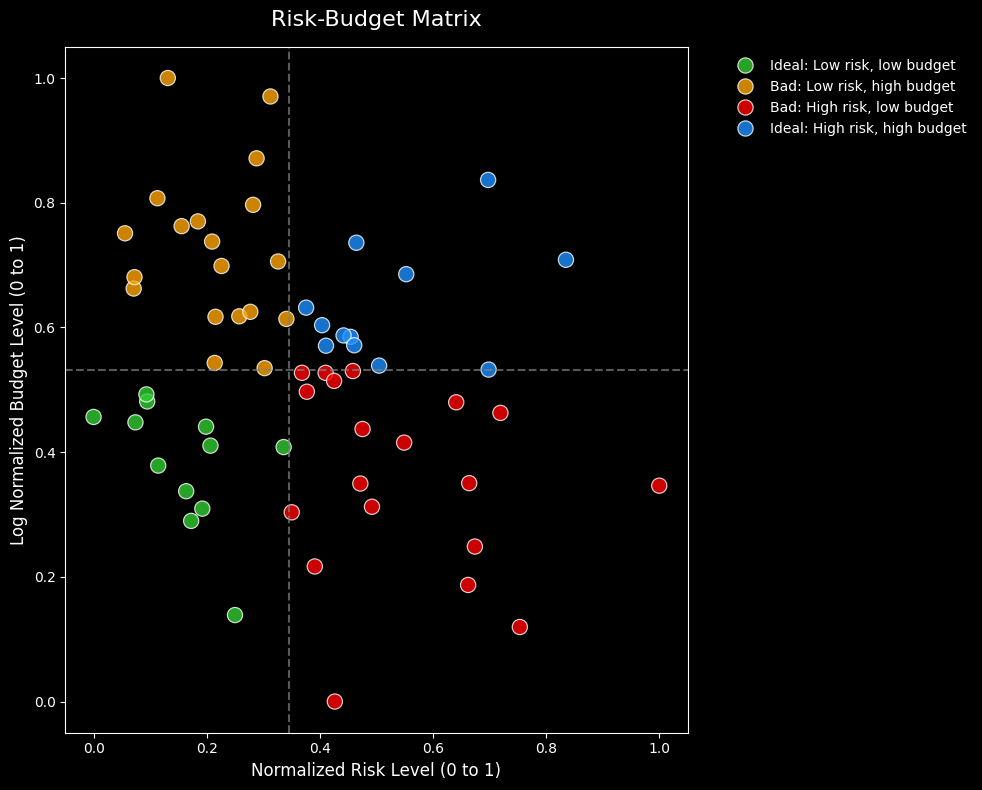

In [40]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 8))

color_map = {
    "Bad: High risk, low budget": "red",
    "Bad: Low risk, high budget": "orange",
    "Ideal: High risk, high budget": "dodgerblue",
    "Ideal: Low risk, low budget": "limegreen"
}

sns.scatterplot(
    data=df,
    x='norm_risk',
    y='norm_budget',
    hue='Matrix_Scenario',
    palette=color_map,
    s=120,
    alpha=0.8,
    edgecolor='white'
)

plt.axvline(risk_mid, color='gray', linestyle='--', alpha=0.7)
plt.axhline(budget_mid, color='gray', linestyle='--', alpha=0.7)

plt.title('Risk-Budget Matrix', fontsize=16, pad=15)
plt.xlabel('Normalized Risk Level (0 to 1)', fontsize=12)
plt.ylabel('Log Normalized Budget Level (0 to 1)', fontsize=12)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()

plt.savefig("Fixed_Matrix_Plot.png", dpi=300)
plt.show()



In [44]:
print(df['risk_score'].describe())
print(df['norm_risk'].describe())
print(df['Total_Budget'].describe())
print(df['norm_budget'].describe())

count   62.00
mean     1.92
std      0.22
min      1.56
25%      1.76
50%      1.91
75%      2.03
max      2.56
Name: risk_score, dtype: float64
count   62.00
mean     0.36
std      0.22
min      0.00
25%      0.20
50%      0.35
75%      0.47
max      1.00
Name: norm_risk, dtype: float64
count               62.00
mean     7,350,829,875.50
std      9,101,267,772.03
min        269,034,200.00
25%      2,283,722,675.26
50%      4,336,536,650.35
75%      9,261,338,466.32
max     50,407,324,027.44
Name: Total_Budget, dtype: float64
count   62.00
mean     0.53
std      0.21
min      0.00
25%      0.41
50%      0.53
75%      0.68
max      1.00
Name: norm_budget, dtype: float64
